In [65]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from networkx.algorithms.d_separation import is_d_separator
from causallearn.utils.cit import CIT
from sklearn.ensemble import RandomForestRegressor

## Generate synthetic data

In [66]:
def generate_random_dag(
    n_obs=8,
    n_latent=0,
    p=0.20,
    rng=None,
    treatment="X",
    outcome="Y",
    force_effect=True,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
):

    if rng is None:
        rng = np.random.default_rng()

    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:
            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            else:
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)

    # get all VASs
    G_backdoor = G.copy()

    # Remove outgoing edges from X
    for child in list(G_backdoor.successors(treatment)):
        G_backdoor.remove_edge(treatment, child)

    adjustment_candidates = [
        node for node in observed_covariates
        if node not in [treatment, outcome]
    ]

    valid_adjustment_sets = []

    for k in range(len(adjustment_candidates) + 1):
        for Z_tuple in itertools.combinations(adjustment_candidates, k):
            Z = set(Z_tuple)

            if is_d_separator(G_backdoor, {treatment}, {outcome}, Z):
                valid_adjustment_sets.append(list(Z_tuple))

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,
        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "valid_adjustment_sets": valid_adjustment_sets,
        "has_valid_adjustment_set": len(valid_adjustment_sets) > 0,
    }

    return graph_info

In [67]:
def simulate_nonlinear_scm(
    graph_info,
    n,
    beta=1.0,
    rng=None,
    noise_scale=1.0,
    intervention=None,
    return_full=False,
):
    """
    Simulate data from a nonlinear SCM.

    For each node i:

        eta_i = sum_{j in Pa(i)} b_{ji} X_j

        X_i = (1 - beta) * eta_i + beta * tanh(eta_i) + epsilon_i

    beta = 0 gives the linear Gaussian SCM.
    beta = 1 gives the fully tanh nonlinear SCM.

    Parameters
    ----------
    graph_info : dict
        Output from generate_random_dag().
    n : int
        Number of samples.
    beta : float
        Nonlinearity strength in [0, 1].
    rng : np.random.Generator
        Random number generator.
    noise_scale : float
        Standard deviation of Gaussian noise.
    intervention : dict or None
        Example: {"X": 1.0}. If given, the specified variable is fixed
        to that value during simulation.
    return_full : bool
        If True, return both observed and full data.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed data only.
    D_full : pd.DataFrame, optional
        Full data including latent variables, returned only if return_full=True.
    """
    if rng is None:
        rng = np.random.default_rng()

    if intervention is None:
        intervention = {}

    order = graph_info["order"]
    observed_nodes = graph_info["observed_nodes"]
    B = graph_info["B"]

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:
        if node in intervention:
            D_full[node] = intervention[node]
            continue

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values
        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    if return_full:
        return D_obs, D_full

    return D_obs

In [68]:
def estimate_true_effect_by_intervention(
    graph_info,
    x="X",
    y="Y",
    x0=-1.0,
    x1=1.0,
    beta=1.0,
    n_mc=100_000,
    rng=None,
    noise_scale=1.0,
):
    """
    Estimate the true nonlinear causal effect by Monte Carlo intervention.

    The estimand is:

        E[Y | do(X=x1)] - E[Y | do(X=x0)]

    This should replace the linear total-effect matrix calculation when beta > 0.

    Parameters
    ----------
    graph_info : dict
        Output from generate_random_dag().
    x : str
        Treatment variable.
    y : str
        Outcome variable.
    x0, x1 : float
        Intervention values.
    beta : float
        Nonlinearity strength used in the SCM.
    n_mc : int
        Monte Carlo sample size.
    rng : np.random.Generator
        Random number generator.
    noise_scale : float
        Standard deviation of Gaussian noise.

    Returns
    -------
    true_effect : float
        Monte Carlo estimate of the interventional causal effect.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Use two child generators so the function is reproducible but independent.
    seed_0, seed_1 = rng.integers(0, 2**32 - 1, size=2)

    _, D0_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_0),
        noise_scale=noise_scale,
        intervention={x: x0},
        return_full=True,
    )

    _, D1_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_1),
        noise_scale=noise_scale,
        intervention={x: x1},
        return_full=True,
    )

    true_effect = D1_full[y].mean() - D0_full[y].mean()

    return true_effect

In [ ]:
def generate_random_nonlinear_dataset(
    n,
    rng,
    n_obs=8,
    n_latent=0,
    p=0.10,
    beta=1.0,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    n_mc_true_effect=100_000,
    signed_coefficients=False,
):
    """

    Returns
    -------
    D_obs : pd.DataFrame
        Observed simulated data.
    B : pd.DataFrame
        Coefficient matrix.
    true_ce : float
        True nonlinear causal effect estimated by intervention.
    graph_info : dict
        Full graph metadata.
    """
    graph_info = generate_random_dag(
        n_obs=n_obs,
        n_latent=n_latent,
        p=p,
        rng=rng,
        treatment=treatment,
        outcome=outcome,
        force_effect=force_effect,
        signed_coefficients=signed_coefficients,
    )

    D_obs = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n,
        beta=beta,
        rng=rng,
        noise_scale=noise_scale,
    )

    x0 = D_obs[treatment].quantile(0.25)
    x1 = D_obs[treatment].quantile(0.75)

    true_ce = estimate_true_effect_by_intervention(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
        beta=beta,
        n_mc=n_mc_true_effect,
        rng=rng,
        noise_scale=noise_scale,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["beta"] = beta
    graph_info["noise_scale"] = noise_scale

    return D_obs, graph_info["B"], true_ce, graph_info

In [ ]:
def estimate_effect_gformula(
    D_obs,
    x="X",
    y="Y",
    Z=None,
    x0=None,
    x1=None,
    model=None,
    random_state=0,
):
    """
    Estimate a nonlinear adjustment effect using the g-formula:

        E_Z[ E[Y | X=x1, Z] - E[Y | X=x0, Z] ]

    This replaces estimate_ate_linear() for nonlinear data.

    Parameters
    ----------
    D_obs : pd.DataFrame
        Observed dataset.
    x : str
        Treatment variable.
    y : str
        Outcome variable.
    Z : list, set, tuple, or None
        Adjustment set.
    x0, x1 : float
        Intervention contrast values.
    model : sklearn-like regressor or None
        If None, use RandomForestRegressor.
    random_state : int
        Random seed for the default random forest.

    Returns
    -------
    effect_hat : float
        Estimated causal effect.
    """
    if Z is None:
        Z = []
    
    if x0 is None:
        x0 = D_obs[x].quantile(0.25),
    
    if x1 is None:
        x1 = D_obs[x].quantile(0.75),

    Z = list(Z)
    features = [x] + Z

    if model is None:
        model = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )

    model.fit(D_obs[features], D_obs[y])

    D_x0 = D_obs[features].copy()
    D_x1 = D_obs[features].copy()

    D_x0[x] = x0
    D_x1[x] = x1

    pred_x0 = model.predict(D_x0)
    pred_x1 = model.predict(D_x1)

    return np.mean(pred_x1 - pred_x0)

## Helper functions

In [71]:
def ci_test(X, Y, Z, D_obs, alpha=0.05, method="kci"):
    """
    Returns True if X and Y are conditionally independent given Z, False otherwise.

    This version uses causal-learn's implemented CI tests.

    Recommended methods:
        method="kci"      -> nonlinear continuous CI test
        method="fisherz"  -> linear Gaussian CI test, useful for sanity checks

    Parameters
    ----------
    X, Y : str
        Variable names.
    Z : list
        Conditioning set.
    D_obs : pd.DataFrame
        Observed data.
    alpha : float
        Significance level. We return independence when p_value > alpha.
    method : str
        causal-learn CI test name, usually "kci" or "fisherz".

    Returns
    -------
    indep : bool
        True if independent, False if dependent.
    p_value : float
        CI test p-value.
    stat : float
        Test statistic. causal-learn's CIT interface returns p-values,
        so stat is set to np.nan for compatibility with your existing code.
    """
    Z = list(Z)

    columns = D_obs.columns.tolist()
    col_to_idx = {col: i for i, col in enumerate(columns)}

    X_idx = col_to_idx[X]
    Y_idx = col_to_idx[Y]
    Z_idx = [col_to_idx[z] for z in Z]

    data_np = D_obs.to_numpy(dtype=float)

    # Cache CIT objects because creating a KCI object for every test is very slow.
    # This avoids creating an additional helper function while keeping your original style.
    cache_key = (id(D_obs), method)

    if not hasattr(ci_test, "_cit_cache"):
        ci_test._cit_cache = {}

    if cache_key not in ci_test._cit_cache:
        ci_test._cit_cache[cache_key] = CIT(data_np, method)

    cit_obj = ci_test._cit_cache[cache_key]

    p_value = cit_obj(X_idx, Y_idx, Z_idx)

    indep = p_value > alpha

    return indep, p_value

In [72]:
def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [73]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [74]:
def r2a(Z, D_obs, x='X', y='Y', alpha_indep=0.1):
    Z = list(Z)

    indep_xy, pval = ci_test(x, y, Z, D_obs, alpha_indep)

    return {
        "R2a": indep_xy,
        "Z": list(Z),
        "cond_indep_x_y_given_Z": indep_xy,
        "pval": pval
    }

In [ ]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.15, max_z_size=None):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, D_obs, x=x, y=y, alpha_indep=alpha_indep)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_effect_gformula(D_obs, x, y, Z) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

In [ ]:
def alg_ea_pc(D_obs, x='X', y='Y', max_z_size= None, alpha_pc=0.05, alpha_dep=0.01, alpha_indep=0.15):
    
    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_z_size is None:
        max_z_size = len(skeleton.nodes) - 2
    else:
        max_z_size = min(max_z_size, len(skeleton.nodes) - 2)

    for l in range(max_z_size + 1):
        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                key = (A, B, Z)

                n_ci_requests += 1

                if key not in ci_cache:
                    n_ci_executed += 1
                    indep, p_value = ci_test(A, B, list(Z), D_obs, alpha=alpha_pc)
                    ci_cache[key] = p_value
                    ci_cache[(B, A, Z)] = p_value

                p_value = ci_cache[key]

                indep_pc = p_value > alpha_pc

                # Entner-style conservative decisions
                dep_entner = p_value < alpha_dep
                indep_entner = p_value > alpha_indep

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Standard PC skeleton update
                if indep_pc and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)

                # Rule 2a
                if pair_is_xy and indep_entner:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a",
                        "Z": list(Z)
                    })

                # Rule 1 hook
                if pair_is_wy and dep_entner and (x not in Z):
                    w = A if A in W else B
                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_r1 = (w, y, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 not in ci_cache:
                        n_ci_executed += 1
                        _, p_r1_followup = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc)
                        ci_cache[key_r1] = p_r1_followup
                        ci_cache[(y, w, Z_plus_x)] = p_r1_followup

                    p_r1_followup = ci_cache[key_r1]

                    if p_r1_followup > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1",
                            "w": w,
                            "Z": list(Z)
                        })

                # Rule 2 hook from cache
                if pair_is_wy and indep_entner:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                if pair_is_wx and dep_entner:
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] > alpha_indep:
                        r2_count += 1
                        found = {
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        }


        if not any_test_possible_this_round:
            break

    if len(r1_hits) > 0 and len(r2_hits) > 0:
        decision = "?"
        vas_list = [hit["Z"] for hit in r1_hits]
        ate = None

    elif len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [estimate_effect_gformula(D_obs, x=x, y=y, Z=Z) for Z in vas_list]
        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets
    }

In [ ]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    method="kci",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            x,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=method,
        )

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            y,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=method,
        )

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy, p_xy = ci_test(
                x,
                y,
                Z,
                D_obs,
                alpha=alpha_indep,
                method=method,
            )

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition:
                # S dependent with Y given Z
                CI_num += 1
                indep_sy_z, p_sy_z = ci_test(
                    S,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=method,
                )
                dep_sy_z = p_sy_z < alpha_dep

                # R1 second condition:
                # S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx, p_sy_zx = ci_test(
                    S,
                    y,
                    Z + [x],
                    D_obs,
                    alpha=alpha_indep,
                    method=method,
                )
                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

                # R2b first condition:
                # S dependent with X given Z
                CI_num += 1
                indep_sx_z, p_sx_z = ci_test(
                    S,
                    x,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=method,
                )
                dep_sx_z = p_sx_z < alpha_dep

                # R2b second condition:
                # S independent of Y given Z
                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

    # Conservative finite-sample decision
    if len(r1_hits) > 0 and len(r2_hits) > 0:
        decision = "?"
        vas_list = []
        ate = None

    elif len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }

In [ ]:
def run_structure_experiment(
    generator,
    structure_name,
    structure_id,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="X",
    outcome="Y",
    alpha_dep=0.01,
    alpha_indep=0.20,
    alpha_pc=0.05
):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):

            seed_seq = np.random.SeedSequence([12345, structure_id, n, rep])
            D_obs, B, true_ce, graph_info = generator(n, np.random.default_rng(seed_seq))
            if hasattr(ci_test, "_cit_cache"):
                ci_test._cit_cache.clear()


            # -------- EHS --------
            # res_ehs = alg_EHS(
            #     D_obs,
            #     x=treatment,
            #     y=outcome,
            #     max_z_size=3,
            #     alpha_dep=alpha_dep,
            #     alpha_indep=alpha_indep
            # )

            # estimated_ce = res_ehs["ATE"]
            # if estimated_ce is None or abs(true_ce) < 1e-3:
            #     RE = None
            # else:
            #     RE = abs(estimated_ce - true_ce) / abs(true_ce)

            # results.append({
            #     "method": "EHS",
            #     "structure": structure_name,
            #     "sample_size": n,
            #     "rep": rep,
            #     "decision": res_ehs["decision"],
            #     "true_ce": true_ce,
            #     "estimated_ce": estimated_ce,
            #     "RE": RE,
            #     "nTest": res_ehs["CI_num"],
            #     "VASs": res_ehs["VASs"],
            #     "R1_count": res_ehs["R1_count"],
            #     "R2_count": res_ehs["R2_count"],
            #     "p_graph": graph_info["p"],
            #     "n_obs": graph_info["n_obs"],
            #     "n_latent": graph_info["n_latent"],
            #     "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
            #     "has_direct_effect": graph_info["has_direct_effect"],
            #     "has_total_effect_path": graph_info["has_total_effect_path"],
            #     "actual_VASs": graph_info["valid_adjustment_sets"]
            # })

            # -------- PC-EA --------
            res_pc_ea = alg_ea_pc(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=None,
                alpha_dep=0.01,
                alpha_indep=0.20,
                alpha_pc=0.05
            )

            estimated_ce = res_pc_ea["ATE"]
            if estimated_ce is None or abs(true_ce) < 1e-3:
                RE = None
            else:
                RE = abs(estimated_ce - true_ce) / abs(true_ce)

            results.append({
                "method": "PC-EA",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "decision": res_pc_ea["decision"],
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_pc_ea["CI_num_executed"],
                "VASs": res_pc_ea["VASs"],
                "R1_count": res_pc_ea["R1_count"],
                "R2_count": res_pc_ea["R2_count"],
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "actual_VASs": graph_info["valid_adjustment_sets"]
            })

            # -------- LSAS --------
            res_lsas = alg_LSAS(
                D_obs,
                x=treatment,
                y=outcome,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                max_z_size=None,
                method="kci",
            )

            decision = res_lsas["decision"]
            estimated_ce = res_lsas["ATE"]
            VASs_lsas = res_lsas["VASs"]

            if estimated_ce is None or abs(true_ce) < 1e-3:
                RE = None
            else:
                RE = abs(estimated_ce - true_ce) / abs(true_ce)

            results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "decision": decision,
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lsas["CI_num"],
                "VASs": VASs_lsas,
                "R1_count": None,
                "R2_count": None, 
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "actual_VASs": graph_info["valid_adjustment_sets"]
            })

    return pd.DataFrame(results)

## Run Experiment

### Experiments Figure 3

In [80]:
results = run_structure_experiment(
    generate_random_nonlinear_dataset,
    structure_name="Random Graphs",
    structure_id = 10,
    sample_sizes = [1500],
    n_reps = 100
)

Running Random Graphs with sample size 1500 for 100 reps...


Processing Random Graphs:   1%|          | 1/100 [25:29<42:04:16, 1529.86s/it]


KeyboardInterrupt: 

In [ ]:
results[results["method"].isin(["EHS", "LSAS"])][
    ["method", "sample_size", "rep", "decision", "estimated_ce", "RE", "R1_count", "R2_count", "VASs"]
]

,method,sample_size,rep,decision,estimated_ce,RE,R1_count,R2_count,VASs
0,EHS,500,0,?,NaN,NaN,19.0,2.0,"[[V4], [V0, V4], [V2, V4], [V3, V4], [V4, V5],..."
2,LSAS,500,0,+,0.070225,0.905992,NaN,NaN,"[[V4], [V3, V4], [V4, V7]]"
3,EHS,500,1,?,NaN,NaN,56.0,9.0,"[[], [V0], [V1], [V3], [V4], [V5], [V6], [V7],..."
5,LSAS,500,1,+,0.408139,0.561278,NaN,NaN,"[[], [V0], [V6], [V7], [V0, V6], [V0, V7], [V6..."
6,EHS,500,2,0,0.000000,1.000000,0.0,7.0,[]
8,LSAS,500,2,?,NaN,NaN,NaN,NaN,[]
9,EHS,500,3,?,NaN,NaN,31.0,7.0,"[[], [V0], [V1], [V2], [V4], [V5], [V6], [V7],..."
11,LSAS,500,3,+,0.725380,0.384495,NaN,NaN,[[]]
12,EHS,500,4,0,0.000000,1.000000,0.0,25.0,[]
14,LSAS,500,4,?,NaN,NaN,NaN,NaN,[]


In [ ]:
results.groupby(["method", "sample_size", "decision"]).size()

method  sample_size  decision
EHS     500          0           2
                     ?           3
        1000         +           2
                     0           1
                     ?           2
LSAS    500          +           3
                     ?           2
        1000         +           3
                     ?           2
PC-EA   500          +           3
                     0           1
                     ?           1
        1000         +           1
                     0           1
                     ?           3
dtype: int64

In [ ]:
summary = (
    results
    .groupby(['method', "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
        
    )
)

summary

,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,EHS,500,1.000000,0.000000,2141.0,0.000000
1,EHS,1000,0.386032,0.532048,2141.0,0.000000
2,LSAS,500,0.617255,0.265216,35.4,15.993749
3,LSAS,1000,0.417780,0.169313,33.2,12.111978
4,PC-EA,500,0.366382,0.434120,80.0,56.307193
5,PC-EA,1000,0.507795,0.696082,67.8,6.723095


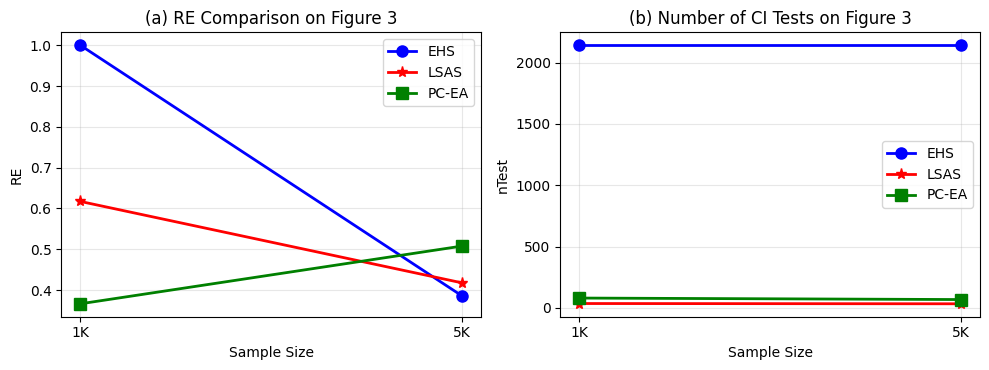

In [ ]:
method_styles = {
    "LSAS": {
        "color": "red",
        "marker": "*"
    },
    "EHS": {
        "color": "blue",
        "marker": "o"
    },
    "PC-EA": {
        "color": "green",
        "marker": "s" 
    }
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for method in summary["method"].unique():
    df_method = summary[summary["method"] == method]

    style = method_styles.get(
        method,
        {"color": "black", "marker": "o"}
    )

    # RE 
    axes[0].plot(
        df_method["sample_size"],
        df_method["mean_RE"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

    # nTest 
    axes[1].plot(
        df_method["sample_size"],
        df_method["mean_nTest"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) RE Comparison on Figure 3")
axes[0].set_xticks(sorted(summary["sample_size"].unique()))
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(b) Number of CI Tests on Figure 3")
axes[1].set_xticks(sorted(summary["sample_size"].unique()))
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()